# Analisi esplorativa delle schede

Notebook automatico per esplorare **completezza, distribuzioni, relazioni e andamento temporale** del dataset.

Le visualizzazioni sono state scelte in base alla natura delle colonne:

- barre e istogrammi per quantità e distribuzioni;
- heatmap per mancanti e associazioni tra variabili categoriche;
- timeline quando è disponibile un anno interpretabile;
- tabelle compatte per le colonne ad alta cardinalità.


In [10]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 14, "axes.labelsize": 11})

FILE_NAME = "dati_schede_min.csv"
candidates = [
    Path(FILE_NAME),
    Path("upload") / FILE_NAME,
    Path("../upload") / FILE_NAME,
]
CSV_PATH = next((p for p in candidates if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        f"Metti {FILE_NAME!r} nella stessa cartella del notebook oppure in una sottocartella 'upload'."
    )

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"File: {CSV_PATH.resolve()}")
print(f"Righe: {len(df):,} | Colonne: {df.shape[1]} | Duplicati completi: {df.duplicated().sum():,}")

File: /mnt/c/Users/gazza/Documents/DOTDOTDOT - summer/FINAL_map/rurale_map_poc/online_map/data/dati_schede_min.csv
Righe: 44,363 | Colonne: 26 | Duplicati completi: 0


## Dashboard unica

La cella seguente crea **una sola figura** con:

1. tutte le variabili e i rispettivi conteggi;
2. tutte le categorie di `tipo_abitazione_rurale`;
3. tutte le categorie di `categoria_edificio`;
4. tutte le categorie di `tipologia_edificio`;
5. la distribuzione di `periodo_cronologico` per secolo;
6. la heatmap dei livelli di rischio.

La riga `fig.savefig(...)` salva l'intera dashboard in un unico file PNG.


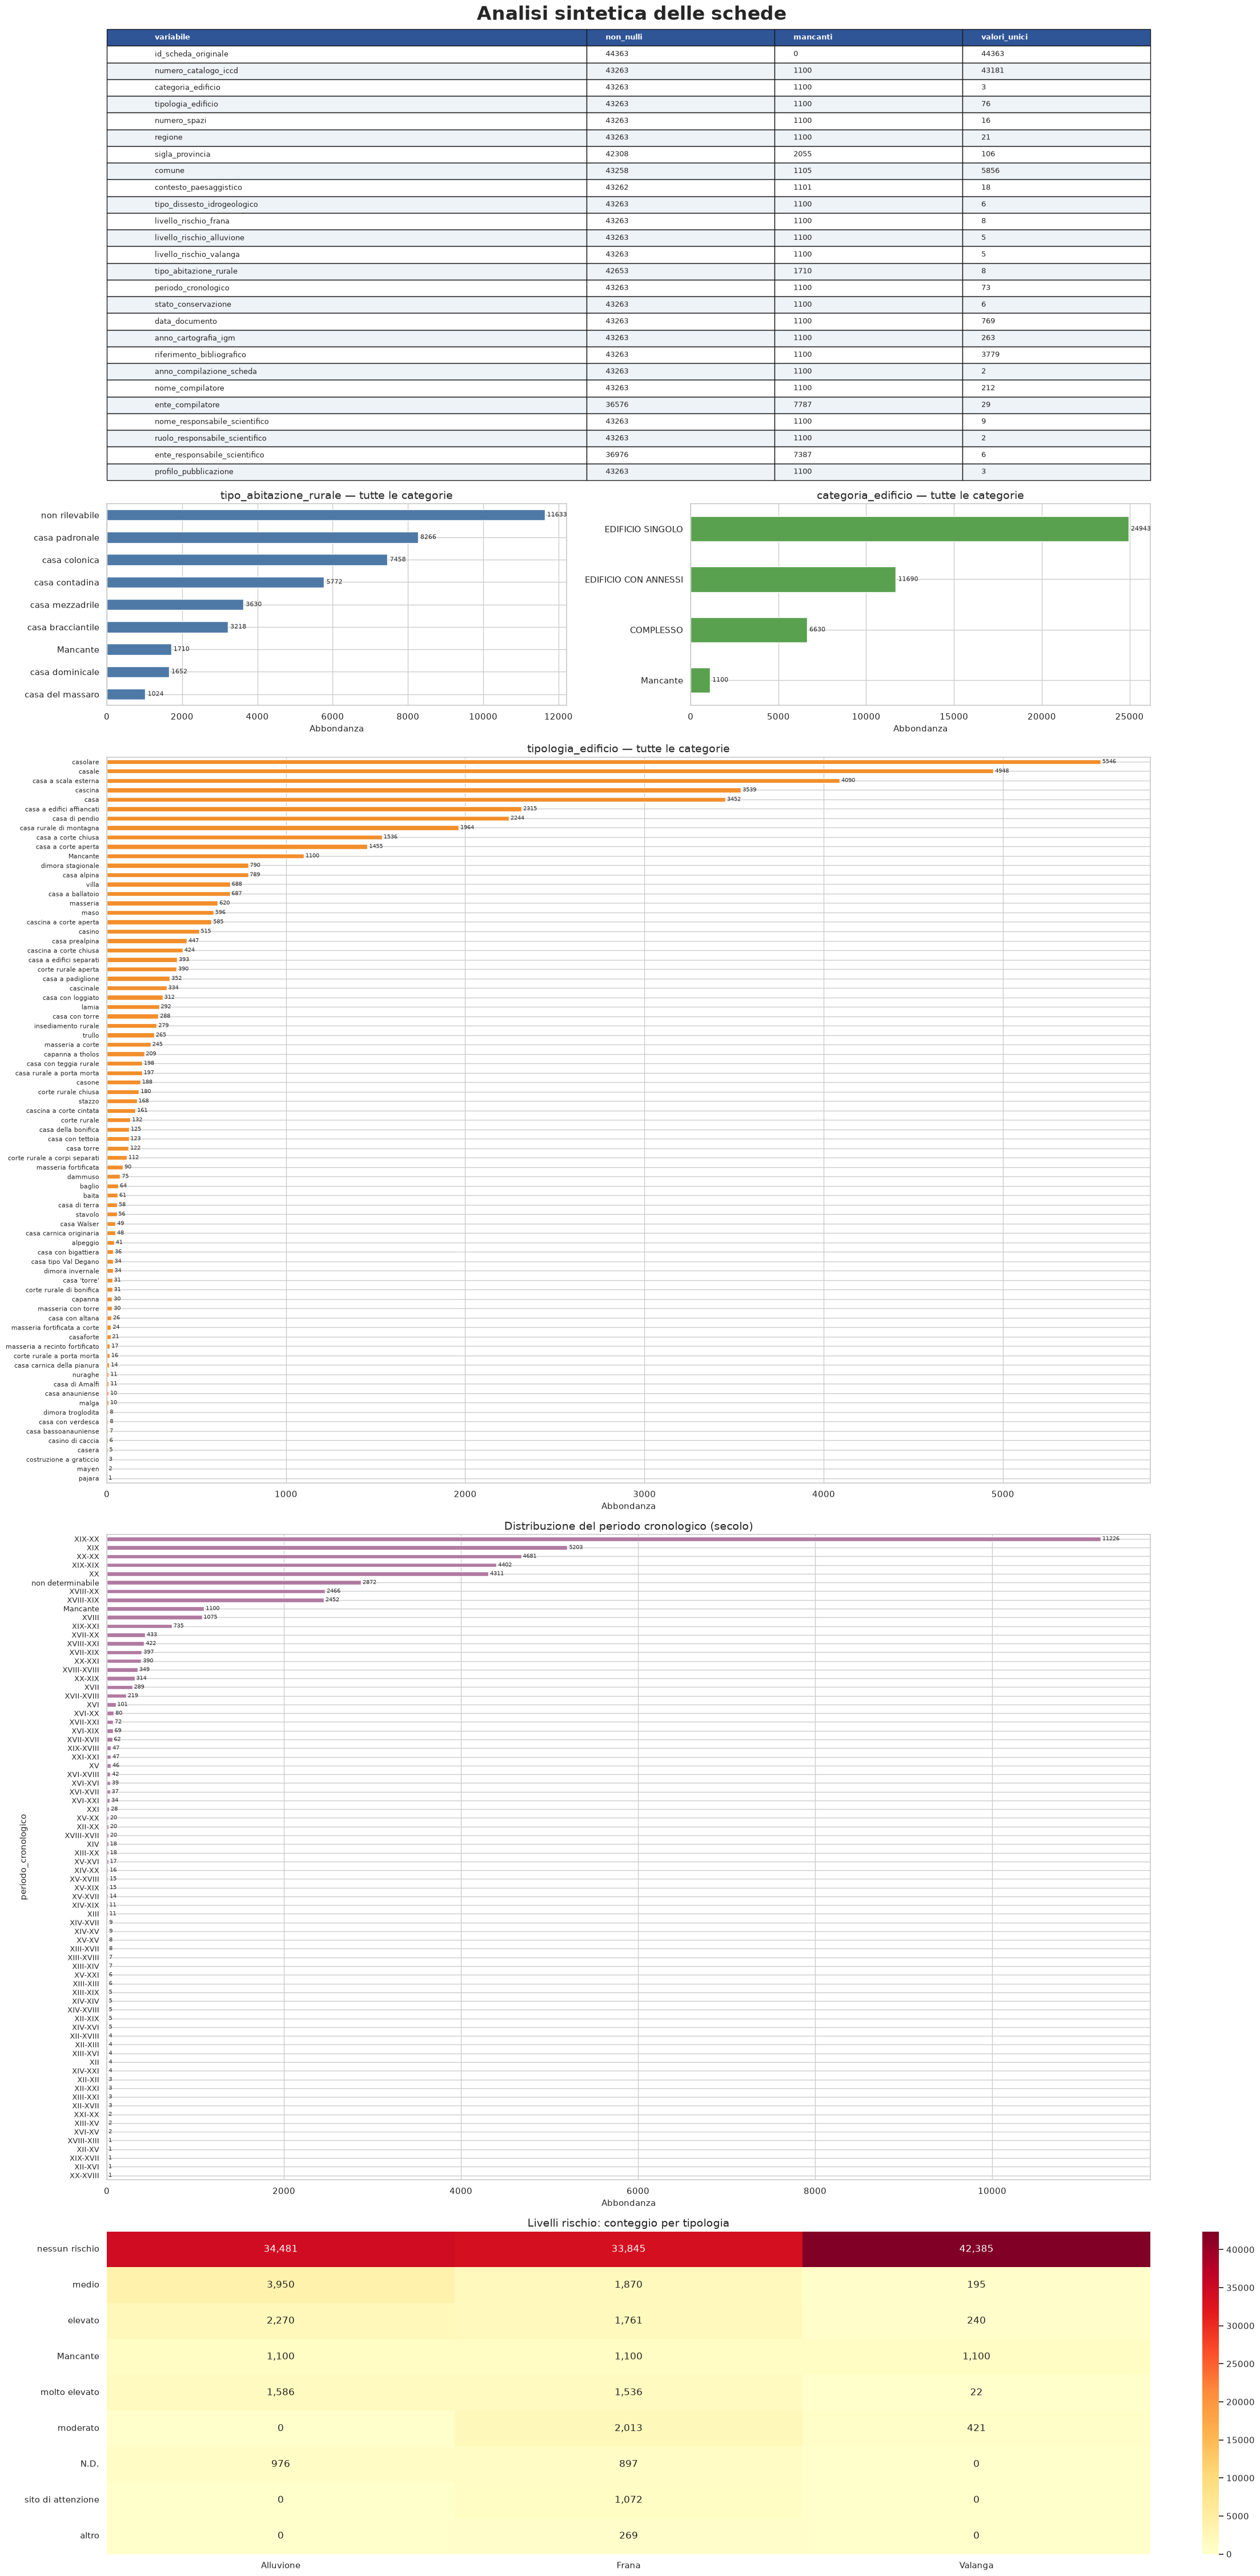

In [12]:
# Conteggi di tutte le variabili: non nulli, mancanti e categorie/valori unici
conteggi_variabili = pd.DataFrame({
    "variabile": df.columns,
    "non_nulli": [df[c].notna().sum() for c in df.columns],
    "mancanti": [df[c].isna().sum() for c in df.columns],
    "valori_unici": [df[c].nunique(dropna=True) for c in df.columns],
})

def tutte_le_categorie(colonna):
    return (
        df[colonna]
        .fillna("Mancante")
        .astype(str)
        .value_counts()
        .sort_values(ascending=True)
    )

abitazione = tutte_le_categorie("tipo_abitazione_rurale")
categoria = tutte_le_categorie("categoria_edificio")
tipologia = tutte_le_categorie("tipologia_edificio")
periodo = tutte_le_categorie("periodo_cronologico")

risk_cols = ["livello_rischio_frana", "livello_rischio_alluvione", "livello_rischio_valanga"]
risk_long = (
    df[risk_cols]
    .rename(columns=lambda c: c.replace("livello_rischio_", "").title())
    .fillna("Mancante")
    .melt(var_name="Rischio", value_name="Livello")
)
tab_risk = pd.crosstab(risk_long["Livello"], risk_long["Rischio"])
tab_risk = tab_risk.loc[tab_risk.sum(axis=1).sort_values(ascending=False).index]

# Figura verticale: l'altezza generosa mantiene leggibili tutte le 76 tipologie.
fig = plt.figure(figsize=(22, 45), constrained_layout=True)
gs = fig.add_gridspec(
    5, 2,
    height_ratios=[8, 5, 18, 16, 8],
    width_ratios=[1, 1],
)
fig.suptitle("Analisi sintetica delle schede", fontsize=24, fontweight="bold")

# In alto: elenco completo delle variabili e relativi conteggi.
ax_table = fig.add_subplot(gs[0, :])
ax_table.axis("off")
table = ax_table.table(
    cellText=conteggi_variabili.values,
    colLabels=conteggi_variabili.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.46, 0.18, 0.18, 0.18],
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.35)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2F5597")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EEF3F8")

ax1 = fig.add_subplot(gs[1, 0])
abitazione.plot.barh(ax=ax1, color="#4E79A7")
ax1.set_title("tipo_abitazione_rurale — tutte le categorie")
ax1.set_xlabel("Abbondanza")
ax1.set_ylabel("")
ax1.bar_label(ax1.containers[0], fmt="%d", padding=3, fontsize=8)

ax2 = fig.add_subplot(gs[1, 1])
categoria.plot.barh(ax=ax2, color="#59A14F")
ax2.set_title("categoria_edificio — tutte le categorie")
ax2.set_xlabel("Abbondanza")
ax2.set_ylabel("")
ax2.bar_label(ax2.containers[0], fmt="%d", padding=3, fontsize=8)

ax3 = fig.add_subplot(gs[2, :])
tipologia.plot.barh(ax=ax3, color="#F28E2B")
ax3.set_title("tipologia_edificio — tutte le categorie")
ax3.set_xlabel("Abbondanza")
ax3.set_ylabel("")
ax3.tick_params(axis="y", labelsize=8)
ax3.bar_label(ax3.containers[0], fmt="%d", padding=2, fontsize=7)

ax4 = fig.add_subplot(gs[3, :])
periodo.plot.barh(ax=ax4, color="#B07AA1")
ax4.set_title("Distribuzione del periodo cronologico (secolo)")
ax4.set_xlabel("Abbondanza")
ax4.set_ylabel("periodo_cronologico")
ax4.tick_params(axis="y", labelsize=9)
ax4.bar_label(ax4.containers[0], fmt="%d", padding=2, fontsize=7)

ax5 = fig.add_subplot(gs[4, :])
sns.heatmap(tab_risk, annot=True, fmt=",", cmap="YlOrRd", ax=ax5)
ax5.set_title("Livelli rischio: conteggio per tipologia")
ax5.set_xlabel("")
ax5.set_ylabel("")

# Una sola riga per salvare l'intera figura.
fig.savefig("dashboard_schede.png", dpi=200, bbox_inches="tight")
plt.show()
